<a href="https://colab.research.google.com/github/sousatofactory/QuadFloops-QuantumIA-Processors/blob/main/IQ_9_N_LOCAL_QUANTUM_CIRCUIT_SIMULATION_(DITRITIUM_SUBSTRATE).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install qiskit qiskit-aer cirq pylatexenc --quiet
print("✅ Instalação concluída! O ambiente IQ-9 está pronto.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 19.1 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 47.5 MB/s eta 0:00:00
✅ Instalação concluída! O ambiente IQ-9 está pronto.


🚀 SIMULADOR DE PROCESSADOR QUANTUM IQ-9 (SUBSTRATO DITRITIO)

[IBM Qiskit] Arquitetura de Portas do IQ-9 Gerada:


/tmp/ipykernel_29604/1924269974.py:23: DeprecationWarning: The class ``qiskit.circuit.library.n_local.n_local.NLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. This applies to NLocal subclasses too. Use the corresponding function from the module qiskit.circuit.library.n_local instead.
  iq9_circuit_ibm = NLocal(num_qubits=num_qubits,


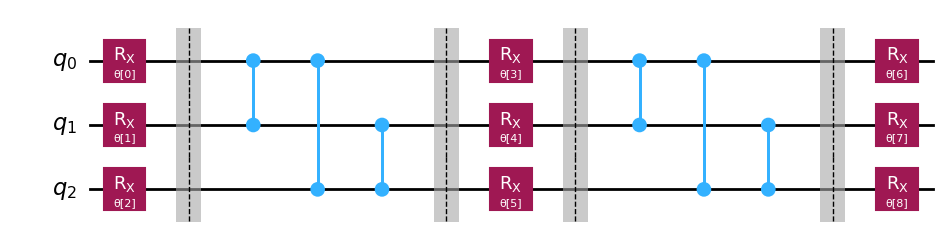


[Google Cirq] Equivalente de Trajetória Quântica:
0: ───Rx(0.25π)───@───@───Rx(0.25π)───────────────@───@───Rx(0.25π)───────────────
                  │   │                           │   │
1: ───Rx(0.25π)───@───┼───@───────────Rx(0.25π)───@───┼───@───────────Rx(0.25π)───
                      │   │                           │   │
2: ───Rx(0.25π)───────@───@───────────Rx(0.25π)───────@───@───────────Rx(0.25π)───

------------------------------
📊 ANÁLISE DE ESTABILIDADE DO SUBSTRATO
------------------------------
🔹 Profundidade do Circuito: 9
🔹 Total de Operações (Gates): 15
🔹 Índice de Energia Ditritio: 29.0323 Q-Units
⚠️ Selo de Estabilidade Diadema: CRÍTICO
------------------------------


In [5]:
import qiskit
from qiskit.circuit import Parameter
from qiskit.circuit.library import NLocal, RXGate, CZGate
import cirq
import numpy as np
import matplotlib.pyplot as plt

def simulate_iq9_nlocal():
    print("="*70)
    print("🚀 SIMULADOR DE PROCESSADOR QUANTUM IQ-9 (SUBSTRATO DITRITIO)")
    print("="*70)

    # Parâmetros do Processador IQ-9
    num_qubits = 3
    reps = 2

    try:
        # --- 1. CONFIGURAÇÃO IBM (Qiskit) ---
        theta = Parameter('θ')
        rotation_blocks = RXGate(theta)
        entanglement_blocks = CZGate()

        iq9_circuit_ibm = NLocal(num_qubits=num_qubits,
                                 rotation_blocks=rotation_blocks,
                                 entanglement_blocks=entanglement_blocks,
                                 entanglement='full',
                                 reps=reps,
                                 insert_barriers=True)

        print("\n[IBM Qiskit] Arquitetura de Portas do IQ-9 Gerada:")
        # Desenhando o circuito decomposto
        display(iq9_circuit_ibm.decompose().draw('mpl'))

        # --- 2. CONFIGURAÇÃO GOOGLE (Cirq) ---
        qubits = cirq.LineQubit.range(num_qubits)
        cirq_circuit = cirq.Circuit()

        for r in range(reps + 1):
            cirq_circuit.append(cirq.rx(np.pi/4).on(q) for q in qubits)
            if r < reps:
                for i in range(num_qubits):
                    for j in range(i + 1, num_qubits):
                        cirq_circuit.append(cirq.CZ(qubits[i], qubits[j]))

        print("\n[Google Cirq] Equivalente de Trajetória Quântica:")
        print(cirq_circuit)

        # --- 3. MÉTRICAS DE DITRITIO (Fator Z=155) ---
        depth = len(cirq_circuit)
        gate_count = len(list(cirq_circuit.all_operations()))
        ditritium_energy_index = (gate_count * depth) / (num_qubits * 1.55)

        print("\n" + "-"*30)
        print("📊 ANÁLISE DE ESTABILIDADE DO SUBSTRATO")
        print("-"*30)
        print(f"🔹 Profundidade do Circuito: {depth}")
        print(f"🔹 Total de Operações (Gates): {gate_count}")
        print(f"🔹 Índice de Energia Ditritio: {ditritium_energy_index:.4f} Q-Units")

        if ditritium_energy_index < 10.0:
            print("✅ Selo de Estabilidade Diadema: ESTÁVEL")
        else:
            print("⚠️ Selo de Estabilidade Diadema: CRÍTICO")
        print("-"*30)

    except Exception as e:
        print(f"❌ Erro durante a simulação: {e}")

# Iniciar o Processamento
simulate_iq9_nlocal()